# YOLOv6 CRP / PCX Explanation Notebook (Person–Vehicle)

This notebook loads a YOLOv6s6 model and a Person–Car dataset, runs (optional) glocal CRP analysis, and visualizes concept-based explanations and reference images.


## 1) Jupyter autoreload (optional)

Keeps imported modules up to date when you edit code.


In [1]:
%load_ext autoreload
%autoreload 2

## 2) Silence noisy loggers (run this early)

Prevents Numba / PIL debug spam in the notebook output.


In [2]:
# --- FIRST CELL (before importing umap/numba!) ---
import os, logging

# Ensure env isn’t forcing DEBUG
os.environ["NUMBA_LOG_LEVEL"] = "WARNING"   # or "ERROR"/"CRITICAL"
os.environ.pop("NUMBA_DEBUG", None)

# Hard‐mute numba loggers and stop propagation to root
for name in ("numba", "numba.core", "numba.core.ssa"):
    lg = logging.getLogger(name)
    lg.setLevel(logging.ERROR)      # try WARNING/ERROR/CRITICAL
    lg.propagate = False
    # remove any existing noisy handlers
    for h in list(lg.handlers):
        lg.removeHandler(h)
    lg.addHandler(logging.NullHandler())

# --- Silence Matplotlib DEBUG logging ---
import os, logging
import matplotlib as mpl

# Just in case someone exported this
os.environ.pop("MPLDEBUG", None)

# Matplotlib's own switch
try:
    mpl.set_loglevel("warning")   # or "error"
except Exception:
    pass

# Force all matplotlib loggers to WARNING and stop propagation to root
for name in ("matplotlib", "matplotlib.font_manager"):
    lg = logging.getLogger(name)
    lg.setLevel(logging.WARNING)   # or logging.ERROR
    lg.propagate = False
    # Remove any existing noisy handlers (e.g., StreamHandler at DEBUG)
    for h in list(lg.handlers):
        lg.removeHandler(h)
    # Add a NullHandler so nothing leaks upward
    lg.addHandler(logging.NullHandler())

# --- Silence PIL/Pillow DEBUG logs ---
import os, logging
os.environ.pop("PILLOW_DEBUG", None)  # just in case

# Force every PIL logger to WARNING (or ERROR) and stop propagation
for name in [n for n in logging.root.manager.loggerDict if n == "PIL" or n.startswith("PIL.")]:
    lg = logging.getLogger(name)
    lg.setLevel(logging.WARNING)      # or logging.ERROR
    lg.propagate = False
    for h in list(lg.handlers):       # remove any noisy handlers
        lg.removeHandler(h)
    lg.addHandler(logging.NullHandler())


## 3) Device selection

Select GPU/CPU device for inference and attribution.


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cuda:6"
print("Using device:", device)


Using device: cuda:6


## 4) Project path setup

Add the repository root so local modules can be imported.


In [4]:
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(sys.path)

['/home/jovyan/FHHI-XAI', '/opt/conda/lib/python311.zip', '/opt/conda/lib/python3.11', '/opt/conda/lib/python3.11/lib-dynload', '', '/opt/conda/lib/python3.11/site-packages']


## 5) Imports

Core imports for dataset loading, analysis, and plotting.


In [5]:
!pip install zennit-crp
!pip install segmentation_models_pytorch
!pip install addict
!pip install natsort

In [6]:
import torch
import torchvision.transforms as transforms
from src.glocal_analysis import run_analysis
from src.plot_crp_explanations import plot_explanations
from src.datasets.person_car_dataset import PersonCarDataset
from LCRP.models import get_model
from src.letterbox_utils import letterbox_transform
import LCRP.models.yolov6 as yolov6

## 6) Load dataset and model


In [7]:
dtype = torch.float32
root_dir = "/home/jovyan/FHHI-XAI/data/RAS_TrialData"

from functools import partial
dataset = PersonCarDataset(root_dir=root_dir, split="train", transform=None)

model_name = "yolov6s6"
ckpt_path = "/home/jovyan/FHHI-XAI/models/best_ckpt.pt"

# Loading unet with path to checkpoint
model = get_model(model_name=model_name, classes=2, ckpt_path=ckpt_path, device=device, dtype=dtype)
model = model.to(device)

### Sanity check


In [8]:
print(len(dataset))

558


## 7) Run analysis and visualize explanations


In [9]:
# This folder contains results of the glocal analysis.
output_dir = "/home/jovyan/FHHI-XAI//output_RAS/crp/yolo_person_car"

### Run glocal analysis (slow; optional)


In [13]:
from PIL import Image
import torchvision.transforms.functional as TF

class ExhaustiveTileDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, tile_size=640, stride=576):
        self.base_dataset = base_dataset
        self.tile_size = tile_size
        self.stride = stride
        self.class_names = getattr(base_dataset, 'class_names', ['person', 'car']) 
        
        # Pre-calculate all tile coordinates to maintain deterministic indexing
        self.tile_mapping = []
        print("Scanning dataset to build exhaustive tile map... This may take a minute.")
        for img_idx in range(len(base_dataset)):
            out = base_dataset[img_idx]
            img = out[0] if isinstance(out, (list, tuple)) else out
            
            # Get dimensions safely
            if isinstance(img, torch.Tensor):
                H, W = img.shape[-2:]
            elif isinstance(img, Image.Image):
                W, H = img.size
            else:
                W, H = Image.fromarray(np.array(img)).size

            xs = list(range(0, W, stride))
            ys = list(range(0, H, stride))
            if xs[-1] + tile_size > W: xs[-1] = max(0, W - tile_size)
            if ys[-1] + tile_size > H: ys[-1] = max(0, H - tile_size)
            
            xs = sorted(list(set(xs)))
            ys = sorted(list(set(ys)))

            for y0 in ys:
                for x0 in xs:
                    self.tile_mapping.append((img_idx, x0, y0))
                    
        print(f"Done! Created {len(self.tile_mapping)} tiles from {len(base_dataset)} full images.")

    def __len__(self):
        return len(self.tile_mapping)
        
    def __getitem__(self, idx):
        img_idx, x0, y0 = self.tile_mapping[idx]
        out = self.base_dataset[img_idx]
        img = out[0] if isinstance(out, (list, tuple)) else out
        target = out[1] if isinstance(out, (list, tuple)) else None
        
        # Convert to PIL for cropping
        if isinstance(img, torch.Tensor):
            img_pil = TF.to_pil_image(img)
        elif isinstance(img, Image.Image):
            img_pil = img
        else:
            img_pil = Image.fromarray(np.array(img))
            
        # Crop the specific tile
        tile_pil = img_pil.crop((x0, y0, x0 + self.tile_size, y0 + self.tile_size))
        tile_tensor = TF.to_tensor(tile_pil)
            
        return tile_tensor, target

    def reverse_normalization(self, x):
        if hasattr(self.base_dataset, 'reverse_normalization'): return self.base_dataset.reverse_normalization(x)
        return x

    def reverse_augmentation(self, x):
        if hasattr(self.base_dataset, 'reverse_augmentation'): return self.base_dataset.reverse_augmentation(x)
        return x
        
    def __getattr__(self, name):
        return getattr(self.base_dataset, name)

exhaustive_dataset = ExhaustiveTileDatasetWrapper(dataset)

# run_analysis(model_name, model, exhaustive_dataset, output_dir=output_dir, device=device)

Scanning dataset to build exhaustive tile map... This may take a minute.
Done! Created 12568 tiles from 558 full images.


Loading reference tiles for Concept 125...


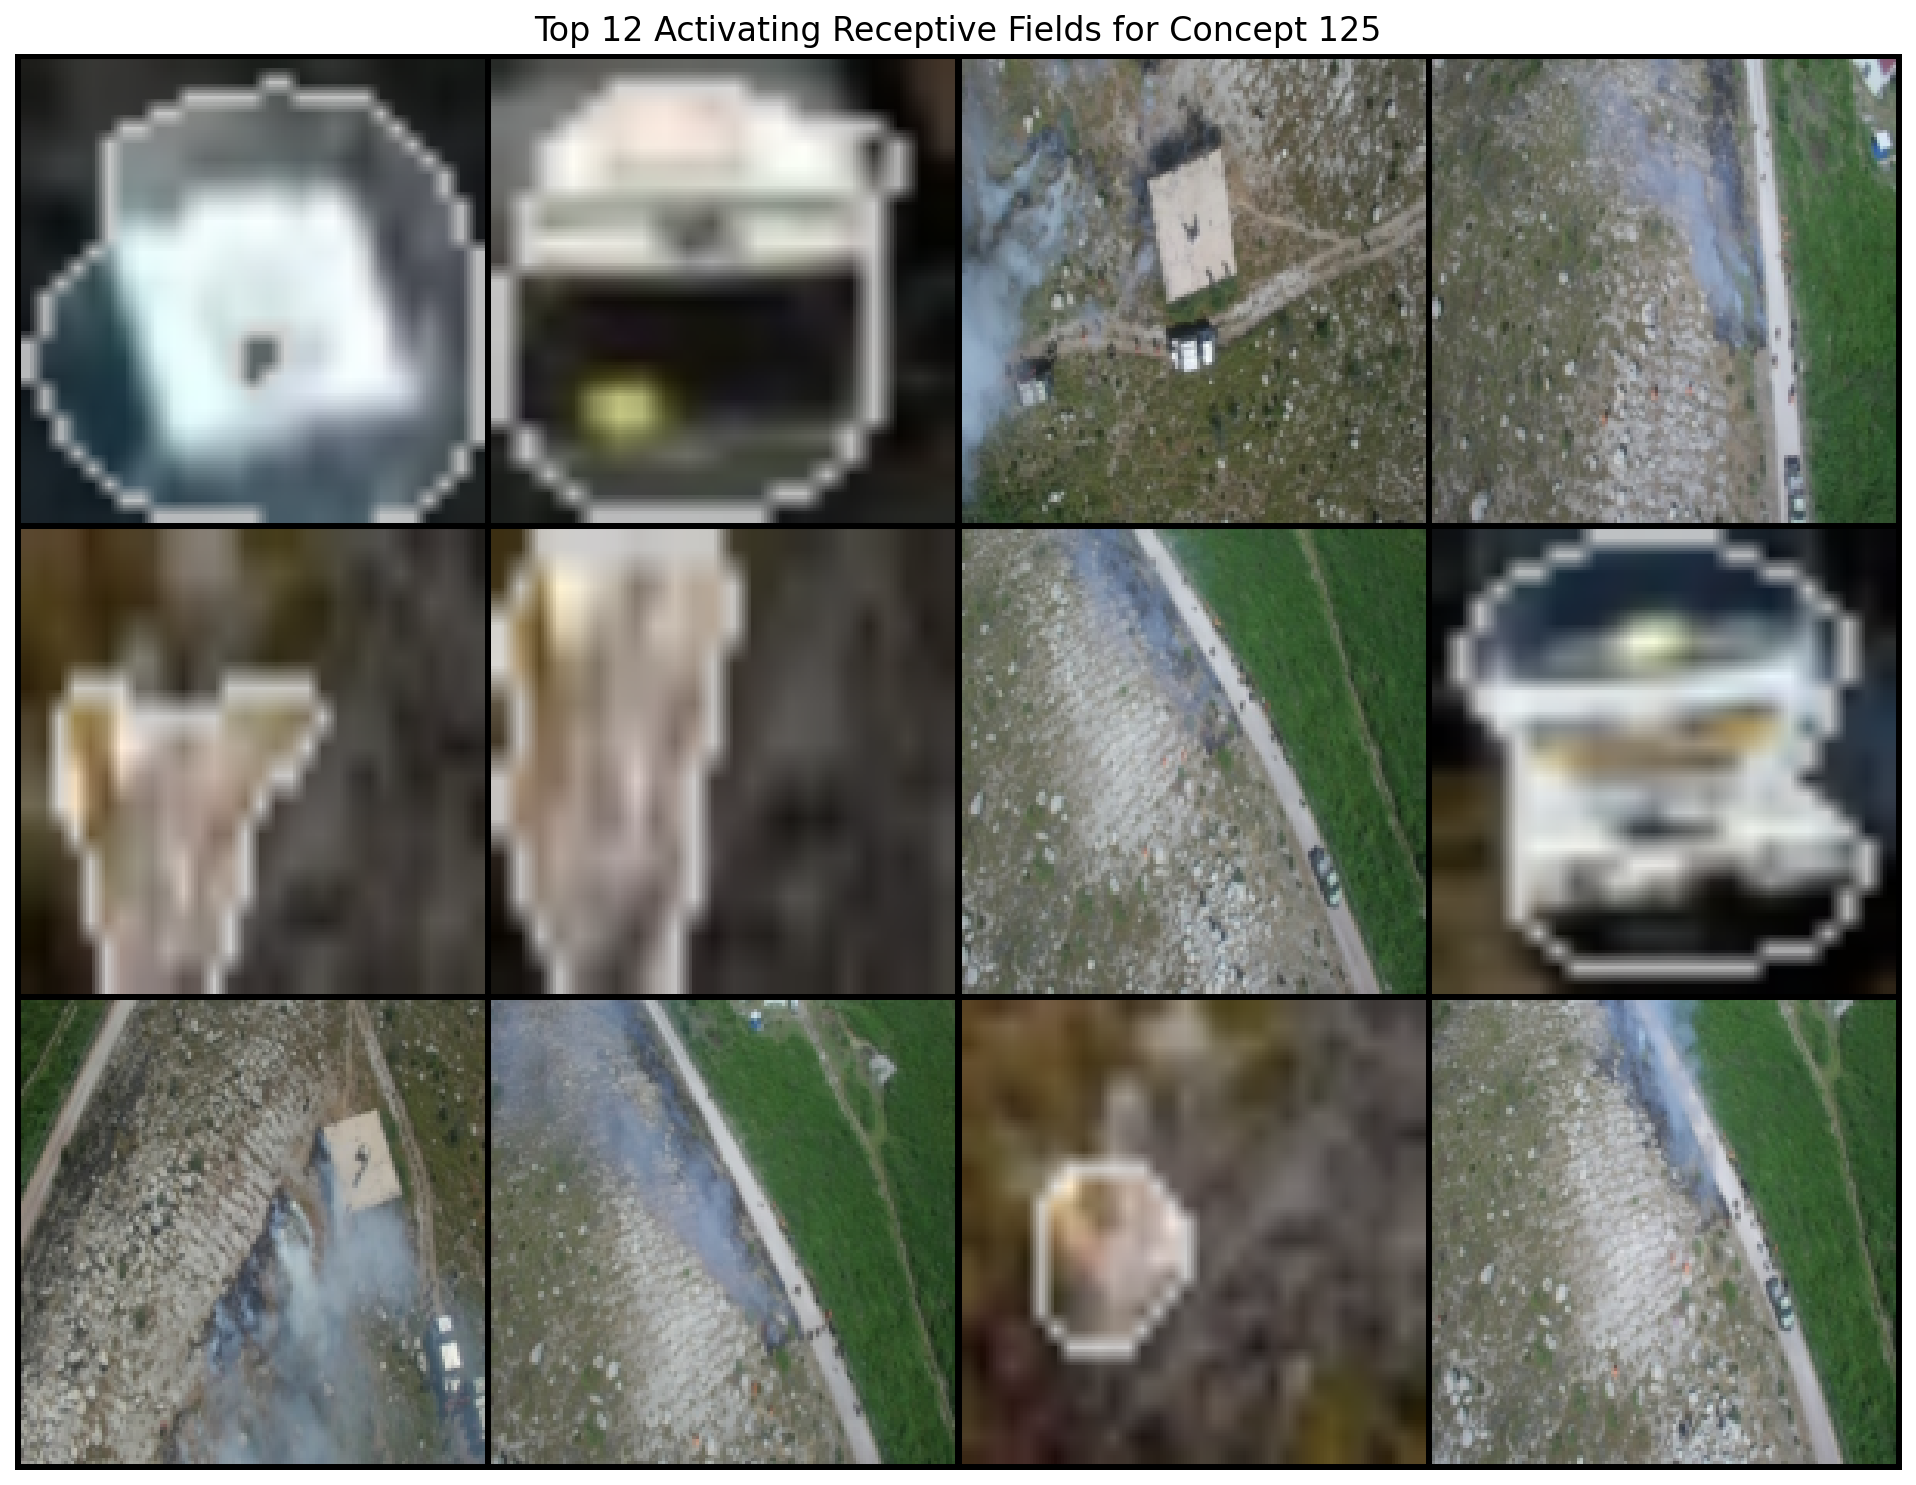

In [16]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision.transforms.functional as TF  # <-- Added for resizing
import zennit.image as zimage
from src.pcx_helper import get_ref_images
from LCRP.utils.crp_configs import ATTRIBUTORS, CANONIZERS, VISUALIZATIONS, COMPOSITES
from crp.helper import get_layer_names

# ==========================================
# SETUP PARAMETERS
# ==========================================
# Change this to any concept number you want to inspect!
concept_to_check = 125 
class_id = 0  # 0 for Person, 1 for Car (depending on your dataset)
layer_to_check = "module.backbone.ERBlock_3.0.rbr_dense.conv"
n_refs = 12

print(f"Loading reference tiles for Concept {concept_to_check}...")

device = next(model.parameters()).device
model = model.eval()

# ==========================================
# INITIALIZE LCRP COMPONENTS
# ==========================================
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
attribution_ref = ATTRIBUTORS[model_name](model)

# We pass the EXACT SAME exhaustive_dataset here so the indices match perfectly
fv_ref = VISUALIZATIONS[model_name](
    attribution_ref, 
    exhaustive_dataset, 
    get_layer_names(model, [torch.nn.Conv2d]),
    preprocess_fn=lambda img: img, 
    path=output_dir, 
    max_target="max", 
    device=str(device)
)

ref_imgs_save_path = os.path.join(os.path.dirname(output_dir), "ref_imgs", f"ref_imgs_{n_refs}")

# ==========================================
# FETCH AND PLOT
# ==========================================
ref_imgs_dict = get_ref_images(
    fv_ref, 
    [concept_to_check], 
    layer_to_check, 
    composite=composite, 
    class_id=class_id, 
    n_ref=n_refs, 
    ref_imgs_save_path=ref_imgs_save_path
)

if ref_imgs_dict and concept_to_check in ref_imgs_dict:
    ref_tiles = ref_imgs_dict[concept_to_check]
    
    # --- BUG FIX: Convert to tensors AND resize them to a uniform size ---
    tensor_tiles = []
    for img in ref_tiles:
        # Convert to PyTorch CHW format
        t = torch.from_numpy(np.array(img)).permute(2, 0, 1)
        # Force a uniform 150x150 size so make_grid can stack them safely
        t = TF.resize(t, [150, 150], antialias=True)
        tensor_tiles.append(t)
    
    # Create a nice 4x3 grid
    grid = make_grid(tensor_tiles, nrow=4, padding=2)
    grid_img = np.array(zimage.imgify(grid.detach().cpu()))
    
    plt.figure(figsize=(15, 10), dpi=150)
    plt.title(f"Top {n_refs} Activating Receptive Fields for Concept {concept_to_check}", fontsize=16)
    plt.imshow(grid_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find reference images for Concept {concept_to_check}. Try a different concept or class_id.")

In [ ]:
.

### Debug: verify saved maximization indices (optional)


In [17]:
# Check the saved_checkpoints or if there were errors
# Look at what indices are actually in the maximization files

import numpy as np

crp_path = "../output_RAS/crp/yolo_person_car"
layer_name = "module.backbone.stem.rbr_dense.conv"  # use one from your list

# Load and check which dataset indices were saved
d_c_sorted = np.load(f"{crp_path}/RelMax_sum_normed/{layer_name}_data.npy")
print(f"Shape: {d_c_sorted.shape}")
print(f"Dataset indices in file (first column): {np.unique(d_c_sorted[:, 0])}")
print(f"Min index: {d_c_sorted.min()}, Max index: {d_c_sorted.max()}")

Shape: (100, 32)
Dataset indices in file (first column): [  258   953  1252  1309  1548  1573  1705  1798  1799  1892  1993  2049
  2395  2451  2469  2470  2471  2485  2493  2501  2509  2510  2513  2517
  2525  2529  2533  2549  2654  2655  2781  2804  2812  2981  2989  3012
  3108  3121  3154  3274  3395  3401  4433  4441  4463  4465  4517  4570
  4625  4673  4705  4713  4720  4721  4737  4777  4833  4854  4855  4857
  4865  4905  4949  4956  4957  4973  5113  5144  5148  5160  5176  5296
  5344  5369  5422  5423  5450  5464  5580  5656  5769  5773  5801  5805
  6105  6273  6328  6405  6408  6832  6836  6844  6868  7212  7651  7747
  7787  8027  9946 11819]
Min index: 9, Max index: 12107


## 8) Generate / save reference images for concept prototypes (optional)


In [19]:
import os
from crp.helper import load_maximization, get_layer_names
from LCRP.utils.render import vis_opaque_img_border
from crp.concepts import ChannelConcept
from src.pcx_helper import get_ref_images
import torch
from LCRP.utils.crp_configs import ATTRIBUTORS, CANONIZERS, VISUALIZATIONS, COMPOSITES

# Setup
model_name = "yolov6s6"
output_dir_crp = "../output_RAS/crp/yolo_person_car"
ref_imgs_path_12 = "../output_RAS/ref_imgs/ref_imgs_12/"
ref_imgs_path_6 = "../output_RAS/ref_imgs/ref_imgs_6/"

# ============================================================
# SPECIFY YOUR LAYERS HERE
# ============================================================
layers_to_process = [
    "module.backbone.stem.rbr_dense.conv",
    "module.backbone.ERBlock_2.0.rbr_dense.conv",
    "module.backbone.ERBlock_3.0.rbr_dense.conv",
]

# Classes to process
class_ids = [1]  # 0=person, 1=car

# Number of reference images to save
n_refs = [12, 6]  # Will save both 12 and 6 ref images

# ============================================================
# Setup CRP components
# ============================================================
# --- FIX 1: Dynamically grab the device ---
device = next(model.parameters()).device

layer_names_all = get_layer_names(model, types=[torch.nn.Conv2d])
attribution = ATTRIBUTORS[model_name](model)
composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])

fv = VISUALIZATIONS[model_name](
    attribution, 
    exhaustive_dataset,  # <-- FIX 2: Use the exhaustive_dataset wrapper here!
    layer_names_all,
    preprocess_fn=lambda x: x,
    path=output_dir_crp,
    max_target="max",
    device=str(device)   # <-- FIX 3: Pass the device here!
)

# ============================================================
# Process each layer
# ============================================================
crp_relmax_path = os.path.join(output_dir_crp, "RelMax_sum_normed")

for layer_name in layers_to_process:
    print(f"\n{'='*60}")
    print(f"Processing layer: {layer_name}")
    print(f"{'='*60}")

    try:
        # Load maximization data to get concept count
        d_c_sorted, _, _ = load_maximization(crp_relmax_path, layer_name)
        n_concepts = d_c_sorted.shape[1]
        print(f"  Layer has {n_concepts} concepts, {d_c_sorted.shape[0]} samples")

        # All concept indices for this layer
        all_concepts = list(range(n_concepts))

        for class_id in class_ids:
            for n_ref in n_refs:
                ref_path = ref_imgs_path_12 if n_ref == 12 else ref_imgs_path_6

                print(f"\n  Class {class_id}, n_ref={n_ref}...")

                try:
                    ref_imgs = get_ref_images(
                        fv, all_concepts, layer_name,
                        composite=composite,
                        class_id=class_id,
                        n_ref=n_ref,
                        ref_imgs_save_path=ref_path,
                        
                    )
                    print(f"    ✓ Saved {len(ref_imgs)} concepts")
                except Exception as e:
                    print(f"    ❌ Error: {e}")

    except Exception as e:
        print(f"  ❌ Error loading layer: {e}")

print("\n" + "="*60)
print("DONE!")
print("="*60)


Processing layer: module.backbone.stem.rbr_dense.conv
  Layer has 32 concepts, 100 samples

  Class 1, n_ref=12...
Reference image file does not exist, calculating all.
torch.Size([23, 8])


ERROR:LCRP.utils.crp:Prediction time: 0.45976686477661133, Backward time: 0.39701080322265625, Full attribution time: 0.40278172492980957


torch.Size([1, 8])


ERROR:LCRP.utils.crp:Prediction time: 0.04603266716003418, Backward time: 0.24981403350830078, Full attribution time: 0.2548942565917969


torch.Size([1, 8])


...

torch.Size([2, 8])


ERROR:LCRP.utils.crp:Prediction time: 0.03844022750854492, Backward time: 0.2132880687713623, Full attribution time: 0.21732258796691895


torch.Size([7, 8])


ERROR:LCRP.utils.crp:Prediction time: 0.038475990295410156, Backward time: 0.21355223655700684, Full attribution time: 0.21735405921936035


    ✓ Saved 128 concepts

DONE!


In [ ]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# import torchvision
# import torchvision.transforms.functional as TF
# from torchvision.utils import draw_bounding_boxes
# from PIL import Image

# # Import native NMS
# from LCRP.models.yolov5 import non_max_suppression

# # ==========================================
# # 1. Helper Functions (Exact match to infer.py)
# # ==========================================
# def generate_positions(length, tile, stride):
#     if length <= tile: return [0]
#     positions, pos = [], 0
#     while True:
#         positions.append(pos)
#         if pos + tile >= length: break
#         pos += stride
#         if pos + tile > length: pos = length - tile
#     return positions

# def tile_ownership_region(x0, y0, tile, W, H, margin):
#     is_left, is_top = (x0 == 0), (y0 == 0)
#     is_right, is_bottom = (x0 + tile >= W), (y0 + tile >= H)
#     left_m = 0 if is_left else margin
#     top_m = 0 if is_top else margin
#     right_m = 0 if is_right else margin
#     bottom_m = 0 if is_bottom else margin
#     ox1 = max(0, min(x0 + left_m, W))
#     oy1 = max(0, min(y0 + top_m, H))
#     ox2 = max(0, min(x0 + tile - right_m, W))
#     oy2 = max(0, min(y0 + tile - bottom_m, H))
#     return ox1, oy1, ox2, oy2

# def global_nms_xyxy(det, iou_thres=0.25):
#     if det is None or len(det) == 0:
#         return det
#     boxes = det[:, :4]
#     scores = det[:, 4]
#     classes = det[:, 5]
#     keep = torchvision.ops.batched_nms(boxes, scores, classes, iou_thres)
#     return det[keep]

# # ==========================================
# # 2. Load the RAW Full-Resolution Image
# # ==========================================
# raw_dataset = PersonCarDataset(root_dir=root_dir, split="train", transform=None)
# sample_idx = 0  
# out = raw_dataset[sample_idx]

# try:
#     raw_img, _ = out
# except Exception:
#     raw_img, _ = out[0], out[1]

# if isinstance(raw_img, torch.Tensor):
#     raw_img = TF.to_pil_image(raw_img)
# elif isinstance(raw_img, np.ndarray):
#     raw_img = Image.fromarray(raw_img)

# W, H = raw_img.size
# print(f"Original Full Image Size: {W}x{H}")

# # ==========================================
# # 3. Setup Tiling Parameters
# # ==========================================
# tile_size = 640
# overlap_px = 64
# stride = tile_size - overlap_px
# margin = max(0, overlap_px // 2)

# xs = generate_positions(W, tile_size, stride)
# ys = generate_positions(H, tile_size, stride)

# print(f"Scanning grid: {len(ys)} rows by {len(xs)} columns ({len(ys)*len(xs)} tiles)...")

# # ==========================================
# # 4. Run Tiled Inference (Tile NMS first!)
# # ==========================================
# all_det = []
# model.eval()
# device = next(model.parameters()).device

# with torch.no_grad():
#     for y0 in ys:
#         for x0 in xs:
#             tile = raw_img.crop((x0, y0, x0 + tile_size, y0 + tile_size))
#             tile_np = np.array(tile)
            
#             # Pad edges
#             th, tw = tile_np.shape[:2]
#             if th != tile_size or tw != tile_size:
#                 padded = np.full((tile_size, tile_size, 3), 114, dtype=tile_np.dtype)
#                 padded[:th, :tw] = tile_np
#                 tile_np = padded
                
#             img_tensor = TF.to_tensor(tile_np).unsqueeze(0).to(device)
            
#             # 1. Raw Prediction
#             raw_output = model.raw_predict(img_tensor)
#             raw_pred = raw_output[0] if isinstance(raw_output, (tuple, list)) else raw_output
            
#             # 2. TILE-LEVEL NMS (Matches your infer.py arg parser default conf_thres=0.35)
#             det_tile = non_max_suppression(raw_pred, conf_thres=0.35, iou_thres=0.45)[0]
            
#             if len(det_tile) == 0:
#                 continue
                
#             # 3. Shift clean boxes to global image space (det_tile is x1, y1, x2, y2)
#             det_tile[:, 0] += x0
#             det_tile[:, 2] += x0
#             det_tile[:, 1] += y0
#             det_tile[:, 3] += y0
            
#             # Clamp to bounds
#             det_tile[:, 0].clamp_(0, W)
#             det_tile[:, 1].clamp_(0, H)
#             det_tile[:, 2].clamp_(0, W)
#             det_tile[:, 3].clamp_(0, H)
            
#             # 4. Tile Ownership filter (prevent duplicate boxes on seams)
#             ox1, oy1, ox2, oy2 = tile_ownership_region(x0, y0, tile_size, W, H, margin)
#             cx = 0.5 * (det_tile[:, 0] + det_tile[:, 2])
#             cy = 0.5 * (det_tile[:, 1] + det_tile[:, 3])
            
#             keep = (cx >= ox1) & (cx < ox2) & (cy >= oy1) & (cy < oy2)
#             det_tile = det_tile[keep]
            
#             if len(det_tile) > 0:
#                 all_det.append(det_tile)

# # ==========================================
# # 5. Global NMS & Plotting
# # ==========================================
# if len(all_det) > 0:
#     det = torch.cat(all_det, dim=0)
    
#     # Global NMS (Normal)
#     det = global_nms_xyxy(det, iou_thres=0.45)
    
#     # Global NMS (Merge seams)
#     final_det = global_nms_xyxy(det, iou_thres=0.1)
# else:
#     final_det = torch.empty((0, 6))

# print(f"Total Objects Detected After Stitching & NMS: {len(final_det)}")

# img_display = TF.to_tensor(raw_img)
# img_display = (img_display * 255).to(torch.uint8)

# if len(final_det) > 0:
#     coords = final_det[:, :4].cpu()
#     result_img = draw_bounding_boxes(img_display, coords, colors="red", width=5)
# else:
#     result_img = img_display

# plt.figure(figsize=(12, 12), dpi=200)
# plt.imshow(result_img.permute(1, 2, 0).numpy())
# plt.axis("off")
# plt.title("YOLOv6 Tiled Inference & Stitched (Exact Replica)")
# plt.tight_layout()
# plt.show()

## 9) Plot explanations for a specific sample

Edit the parameters below and run the `plot_explanations(...)` call.


In [ ]:
# # Setting up main parameters
# class_id = 0 #1/2
# sample_id = 0 #data number in the dataset
# n_concepts =  3 #jj
# n_refimgs = 12 # constant
# layer = "module.backbone.ERBlock_3.0.rbr_dense.conv" # change the layer
# mode = "relevance"
# prediction_num = 0 

# # if failing, try to restart the notebook and do not run analysis again, go directly to plotting
# plot_explanations(model_name, model, dataset, sample_id, class_id, layer, prediction_num, mode, n_concepts, n_refimgs, output_dir=output_dir)

Scanning 4K Image 0 for objects of Class 1...
torch.Size([0, 6])
torch.Size([0, 6])
torch.Size([0, 6])
torch.Size([0, 6])
torch.Size([0, 6])
torch.Size([0, 6])
torch.Size([1, 8])
torch.Size([10, 8])
Object found at X=576, Y=576! Generating perfectly aligned L-CRP explanation...
torch.Size([10, 8])


ERROR:LCRP.utils.crp:Prediction time: 0.05522656440734863, Backward time: 0.23335599899291992, Full attribution time: 0.23723149299621582


torch.Size([10, 8])
torch.Size([10, 8])


ERROR:LCRP.utils.crp:Prediction time: 0.05419421195983887, Backward time: 0.31179118156433105, Full attribution time: 0.3157007694244385


Loading reference images...
Plotting perfectly aligned grid...


/tmp/ipykernel_39316/2484741031.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


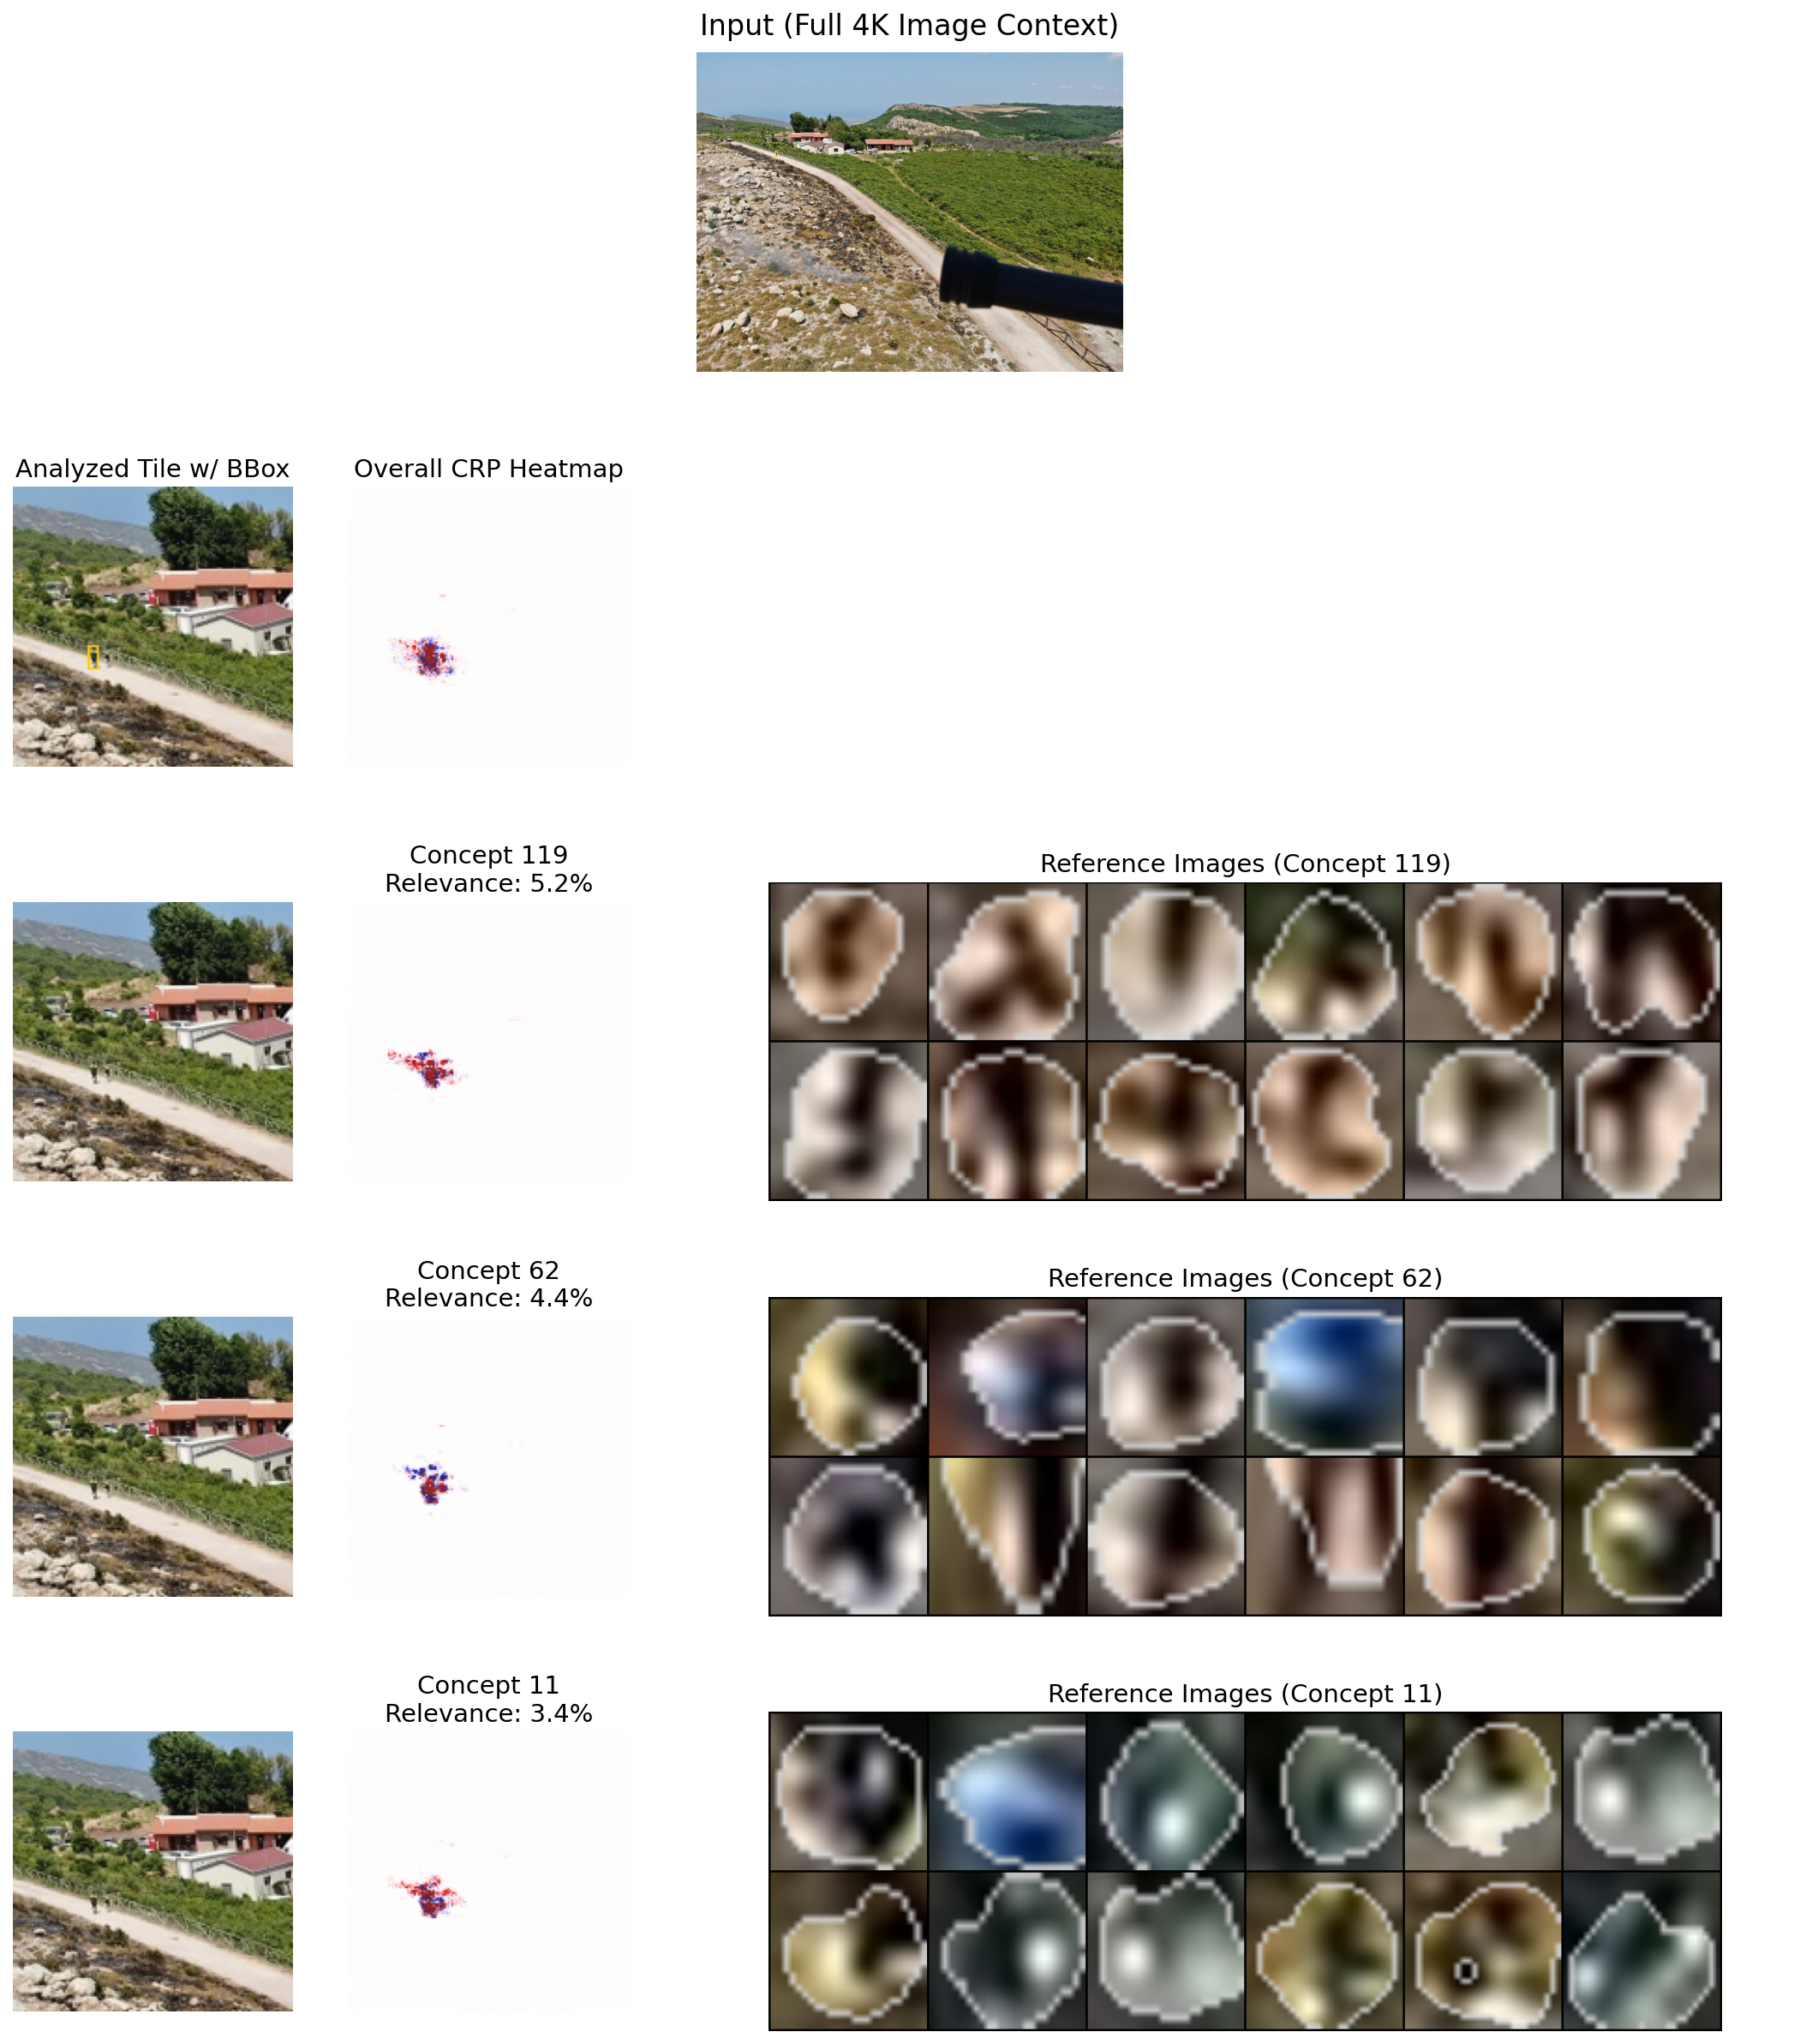

Done plotting.


In [24]:
import os
import sys
import gc
import time
import logging

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import torch
import torchvision
import torchvision.transforms.functional as F
from torchvision.utils import draw_bounding_boxes, make_grid
from PIL import Image
import zennit.image as zimage

from crp.concepts import ChannelConcept
from crp.helper import get_layer_names

logger = logging.getLogger(__name__)

from LCRP.utils.crp_configs import ATTRIBUTORS, CANONIZERS, VISUALIZATIONS, COMPOSITES
from src.pcx_helper import get_ref_images

DISPLAY_SIZE = 150

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def _to_2d(array):
    arr = np.array(array)
    arr = np.squeeze(arr)
    if arr.ndim == 2: return arr
    if arr.ndim == 3:
        if arr.shape[0] <= 4 and arr.shape[1] > 10 and arr.shape[2] > 10: return arr.max(axis=0)
        if arr.shape[2] <= 4 and arr.shape[0] > 10 and arr.shape[1] > 10: return arr.mean(axis=2)
        if arr.shape[0] == 1: return arr[0]
        return arr.mean(axis=0)
    idx = list(np.argsort(arr.shape)[-2:])
    perm = [i for i in range(arr.ndim) if i not in idx] + idx
    arr = np.transpose(arr, perm)
    while arr.ndim > 2: arr = arr.mean(axis=0)
    return arr

def _colorize_signed_map(raw_map, cmap_name="seismic", clip_percentile=99.5, power=1.15, saturation=0.85):
    map2d = _to_2d(raw_map).astype("float32")
    if map2d.size == 0: return np.zeros((1, 1, 3), dtype=np.float32)
    abs_values = np.abs(map2d)
    scale = np.percentile(abs_values, clip_percentile)
    if scale <= 0: scale = abs_values.max()
    if scale <= 0: return np.zeros(map2d.shape + (3,), dtype=np.float32)
    normalized = np.clip(map2d / (scale + 1e-12), -1.0, 1.0)
    normalized = np.sign(normalized) * (np.abs(normalized) ** power)
    cmap = plt.colormaps.get_cmap(cmap_name)
    colored = cmap((normalized + 1.0) / 2.0)[..., :3]
    colored = colored * saturation + (1.0 - saturation)
    return colored

def _resize_for_display(array, size=DISPLAY_SIZE):
    arr = np.array(array)
    if arr.size == 0: return arr
    if arr.ndim == 3 and arr.shape[2] == 1: arr = arr[:, :, 0]

    tensor = torch.from_numpy(arr).float()
    if tensor.ndim == 2: tensor = tensor.unsqueeze(0).unsqueeze(0)
    elif tensor.ndim == 3: tensor = tensor.permute(2, 0, 1).unsqueeze(0)
    else: tensor = tensor.reshape(1, 1, *tensor.shape[-2:])

    if tensor.max() > 1.0: tensor = tensor / 255.0
    if tensor.min() < 0.0:
        tensor = tensor - tensor.min()
        if tensor.max() > 0: tensor = tensor / tensor.max()

    resized = torch.nn.functional.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False).squeeze(0)
    return np.clip(resized.permute(1, 2, 0).cpu().numpy(), 0.0, 1.0)


# ==========================================
# MAIN PLOTTING LOGIC
# ==========================================
def plot_one_image_explanation_optimized(model_name, model, raw_img_pil, x0, y0, tile_size, dataset, class_id, layer, prediction_num, mode, n_concepts, n_refimgs, output_dir):
    device = next(model.parameters()).device
    model = model.to(device).eval()

    composite = COMPOSITES[model_name](canonizers=[CANONIZERS[model_name]()])
    condition = [{"y": class_id}]

    # 1. Extract the Tile for CRP Math (Prevents OOM)
    tile_pil = raw_img_pil.crop((x0, y0, x0 + tile_size, y0 + tile_size))
    img_tensor = F.to_tensor(tile_pil).unsqueeze(0).to(device)

    # 2. Run Attribution
    attribution = ATTRIBUTORS[model_name](model)
    attribution.take_prediction = prediction_num
    x = img_tensor.detach().requires_grad_(True)
    attr = attribution(x, condition, composite, record_layer=[layer], init_rel=1)

    raw_heat = attr.heatmap.detach().cpu().numpy()
    heatmap_display = _resize_for_display(_colorize_signed_map(raw_heat), DISPLAY_SIZE)

    # 3. Extract YOLO Boxes
    preds = model.predict_with_boxes(img_tensor)
    predicted_boxes = preds[1][0]
    predicted_classes = attr.prediction.argmax(dim=2)[0]
    
    sorted_idx = attr.prediction.max(dim=2)[0].argsort(descending=True)[0]
    predicted_classes = predicted_classes[sorted_idx]
    predicted_boxes = predicted_boxes[sorted_idx]
    
    target_boxes = [b for b, c in zip(predicted_boxes, predicted_classes) if c == class_id]
    if len(target_boxes) <= prediction_num:
        raise ValueError(f"No object of class {class_id} found in this tile.")

    # Draw local bounding box on the tile
    local_box = target_boxes[prediction_num].clone().detach().cpu()
    local_boxes = local_box[:4].unsqueeze(0) 
    
    base_img_uint8 = F.to_tensor(tile_pil).mul(255).byte()
    local_result = draw_bounding_boxes(base_img_uint8, local_boxes, colors=["#ffcc00"], width=5)
    segmentation_display = _resize_for_display(np.asarray(F.to_pil_image(local_result)), DISPLAY_SIZE)
    raw_tile_display = _resize_for_display(np.asarray(tile_pil), DISPLAY_SIZE)

    # Draw Global bounding box on the 4K image
    global_box = local_box[:4].clone()
    global_box[0] += x0; global_box[2] += x0
    global_box[1] += y0; global_box[3] += y0
    
    full_img_uint8 = F.to_tensor(raw_img_pil).mul(255).byte()
    global_result = draw_bounding_boxes(full_img_uint8, global_box.unsqueeze(0), colors=["#ffcc00"], width=8)
    full_4k_display = np.asarray(F.to_pil_image(global_result))

    # 4. Extract Concepts
    if mode == "relevance":
        channel_rels = ChannelConcept().attribute(attr.relevances[layer], abs_norm=True)
    else:
        channel_rels = attr.activations[layer].detach().cpu().flatten(start_dim=2).max(2)[0]
        channel_rels = channel_rels / channel_rels.abs().sum(1)[:, None]

    topk = torch.topk(channel_rels[0], n_concepts)
    topk_ind = topk.indices.detach().cpu().numpy()
    topk_rel = topk.values.detach().cpu().numpy()

    # Conditional heatmaps
    conditions = [{"y": class_id, layer: c} for c in topk_ind]
    attribution_cond = ATTRIBUTORS[model_name](model)
    attribution_cond.take_prediction = prediction_num
    cond_heatmap, _, _, _ = attribution_cond(
        img_tensor.detach().requires_grad_(True), conditions, composite,
        record_layer=[layer], init_rel=1, exclude_parallel=True
    )

    # Load Reference Images
    print("Loading reference images...")
    
    # --- FIX 1: Exact Path Matching to your batch script output ---
    ref_imgs_save_path = f"../output_RAS/ref_imgs/ref_imgs_{n_refimgs}"

    # --- FIX 2: Provide a safe Dataset wrapper just in case a concept needs calculating ---
    class RefDatasetWrapper(torch.utils.data.Dataset):
        def __init__(self, base_dataset):
            self.base_dataset = base_dataset
            self.class_names = getattr(base_dataset, 'class_names', ['person', 'car']) 
        def __len__(self): return len(self.base_dataset)
        def __getitem__(self, idx):
            out = self.base_dataset[idx]
            img = out[0] if isinstance(out, (list, tuple)) else out
            target = out[1] if isinstance(out, (list, tuple)) else None
            if isinstance(img, torch.Tensor): img = F.resize(img, (640, 640), antialias=True)
            elif isinstance(img, Image.Image): img = F.to_tensor(F.resize(img, (640, 640)))
            else: img = F.to_tensor(F.resize(Image.fromarray(np.array(img)), (640, 640)))
            return img, target
        def reverse_normalization(self, x):
            if hasattr(self.base_dataset, 'reverse_normalization'): return self.base_dataset.reverse_normalization(x)
            return x
        def __getattr__(self, name): return getattr(self.base_dataset, name)

    tensor_ref_dataset = RefDatasetWrapper(dataset)

    fv_ref = VISUALIZATIONS[model_name](
        attribution_ref, tensor_ref_dataset, get_layer_names(model, [torch.nn.Conv2d]),
        preprocess_fn=lambda x: x, path=output_dir, max_target="max", device=str(device)
    )
    
    ref_imgs = get_ref_images(
        fv_ref, topk_ind.tolist(), layer, composite=composite, class_id=class_id,
        n_ref=n_refimgs, ref_imgs_save_path=ref_imgs_save_path
    )

    # ==========================================
    # PERFECT GRID ALIGNMENT PLOTTING
    # ==========================================
    print("Plotting perfectly aligned grid...")
    total_rows = n_concepts + 2 # Row 0: 4K, Row 1: Overall, Row 2+: Concepts
    ref_width = max(2, n_refimgs // 3)
    
    fig = plt.figure(figsize=(10 + ref_width * 2, 4 * total_rows), dpi=150)
    gs = GridSpec(total_rows, 3, figure=fig, width_ratios=[1, 1, ref_width], hspace=0.3, wspace=0.1)

    # --- ROW 0: FULL 4K IMAGE ---
    ax_full = fig.add_subplot(gs[0, :]) # Spans across all 3 columns
    ax_full.set_title("Input (Full 4K Image Context)", fontsize=16, pad=10)
    ax_full.imshow(full_4k_display)
    ax_full.axis("off")

    # --- ROW 1: OVERALL CRP ---
    ax_in = fig.add_subplot(gs[1, 0])
    ax_in.set_title("Analyzed Tile w/ BBox", fontsize=14)
    ax_in.imshow(segmentation_display)
    ax_in.axis("off")

    ax_hm = fig.add_subplot(gs[1, 1])
    ax_hm.set_title("Overall CRP Heatmap", fontsize=14)
    ax_hm.imshow(heatmap_display)
    ax_hm.axis("off")

    ax_empty = fig.add_subplot(gs[1, 2])
    ax_empty.axis("off") # Leave Col 3 empty on Row 1

    # --- ROW 2+: CONCEPTS ---
    resize = torchvision.transforms.Resize((150, 150))
    for i in range(n_concepts):
        r = i + 2
        
        # Col 0: Raw Tile
        ax_c_in = fig.add_subplot(gs[r, 0])
        ax_c_in.imshow(raw_tile_display)
        ax_c_in.axis("off")
        
        # Col 1: Conditional Heatmap
        ax_c_hm = fig.add_subplot(gs[r, 1])
        cond_map = cond_heatmap[i].detach().cpu().numpy()
        cond_vis = _colorize_signed_map(cond_map)
        ax_c_hm.imshow(_resize_for_display(cond_vis, DISPLAY_SIZE))
        ax_c_hm.set_title(f"Concept {topk_ind[i]}\nRelevance: {topk_rel[i] * 100:.1f}%", fontsize=14)
        ax_c_hm.axis("off")
        
        # Col 2: Reference Images
        ax_c_ref = fig.add_subplot(gs[r, 2])
        if ref_imgs and topk_ind[i] in ref_imgs:
            resized_refs = [resize(torch.from_numpy(np.array(img)).permute((2, 0, 1))) for img in ref_imgs[topk_ind[i]]]
            grid = make_grid(resized_refs, nrow=max(1, n_refimgs // 2), padding=2)
            ax_c_ref.imshow(np.array(zimage.imgify(grid.detach().cpu())))
        ax_c_ref.set_title(f"Reference Images (Concept {topk_ind[i]})", fontsize=14)
        ax_c_ref.axis("off")

    plt.tight_layout()
    torch.cuda.empty_cache()
    gc.collect()
    return fig


def plot_explanations(model_name, model, raw_img, x0, y0, tile_size, dataset, class_id, layer, prediction_num, mode, n_concepts, n_refimgs, output_dir):
    try:
        if torch.cuda.is_available(): 
            try: torch.cuda.reset_peak_memory_stats()
            except AttributeError: torch.cuda.reset_max_memory_allocated()
                
        fig = plot_one_image_explanation_optimized(
            model_name, model, raw_img, x0, y0, tile_size, dataset, class_id, layer, prediction_num, mode, n_concepts, n_refimgs, output_dir
        )
        plt.show()
        print("Done plotting.")
    except Exception as e:
        print(f"Error during explanation: {e}")
        raise
    finally:
        gc.collect()
        torch.cuda.empty_cache()

# ==========================================
# EXECUTE 
# ==========================================
# Parameters
class_id = 1 
sample_id = 0 
n_concepts = 3 
n_refimgs = 12 
layer = "module.backbone.ERBlock_3.0.rbr_dense.conv" 
mode = "relevance"
prediction_num = 0 

dataset = PersonCarDataset(root_dir=root_dir, split="train", transform=None)

# 1. Fetch raw 4K image
out = dataset[sample_id]
raw_img = out[0] if isinstance(out, (list, tuple)) else out
if isinstance(raw_img, torch.Tensor): raw_img = F.to_pil_image(raw_img)
elif isinstance(raw_img, np.ndarray): raw_img = Image.fromarray(raw_img)

W, H = raw_img.size
tile_size, stride = 640, 576

# 2. Scan to find the target object
best_x0, best_y0 = None, None
model.eval()
dev = next(model.parameters()).device

print(f"Scanning 4K Image {sample_id} for objects of Class {class_id}...")
with torch.no_grad():
    for y0 in range(0, H - tile_size + 1, stride):
        for x0 in range(0, W - tile_size + 1, stride):
            tile = raw_img.crop((x0, y0, x0 + tile_size, y0 + tile_size))
            tile_tensor = F.to_tensor(tile).unsqueeze(0).to(dev)
            
            preds = model.predict_with_boxes(tile_tensor)
            if len(preds[1][0]) > 0:
                pred_classes = preds[0].argmax(dim=2)[0]
                if class_id in pred_classes:
                    best_x0, best_y0 = x0, y0
                    break
        if best_x0 is not None: break

if best_x0 is None:
    print(f"Could not find any objects of class {class_id} in sample {sample_id}.")
else:
    print(f"Object found at X={best_x0}, Y={best_y0}! Generating perfectly aligned L-CRP explanation...")
    
    # 3. Pass the 4K image and coordinates directly to the plotting function
    plot_explanations(
        model_name, model, raw_img, best_x0, best_y0, tile_size, 
        dataset, class_id, layer, prediction_num, mode, n_concepts, n_refimgs, output_dir=output_dir
    )